In [9]:
import os
os.chdir("/Users/cherie/Desktop/quantum-gates/src")  # or any folder that actually exists
print(os.getcwd())

from quantum_gates._utility.RotatedSurfaceCodeLoom import RotatedSurfaceCodeLoom
import matplotlib.pyplot as plt
import numpy as np

/Users/cherie/Desktop/quantum-gates/src


In [2]:
code = RotatedSurfaceCodeLoom(3, 5, 10000, True)

In [ ]:
logical_error_rate = code.run_circ("AER")

In [13]:
def plot_results(results):    
    # Plot
    p_values = [r[0] for r in results]
    ler_values = [r[1] for r in results]

    plt.figure(figsize=(8, 6))
    plt.plot(p_values, ler_values, 'bo-', label='Logical error rate (d=3)', linewidth=2, markersize=8)
    plt.plot(p_values, p_values, 'r--', label='Physical error rate (LER = p)', linewidth=2)
    plt.xlabel('Physical error rate p', fontsize=13)
    plt.ylabel('Logical error rate', fontsize=13)
    plt.title('Distance-3 Rotated Surface Code — Logical vs Physical Error Rate', fontsize=13)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(fontsize=12)
    plt.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.savefig('surface_code_ler.png', dpi=150)
    plt.show()
    print("Plot saved to surface_code_ler.png")

p=0.000 → LER=0.0000  SUPPRESSED ✓
p=0.000 → LER=0.0000  SUPPRESSED ✓
p=0.000 → LER=0.0000  SUPPRESSED ✓
p=0.000 → LER=0.0000  SUPPRESSED ✓
p=0.000 → LER=0.0000  SUPPRESSED ✓
p=0.001 → LER=0.0000  SUPPRESSED ✓
p=0.001 → LER=0.0004  SUPPRESSED ✓
p=0.001 → LER=0.0003  SUPPRESSED ✓
p=0.002 → LER=0.0019  WORSE THAN PHYSICAL ✗
p=0.003 → LER=0.0042  WORSE THAN PHYSICAL ✗
p=0.004 → LER=0.0059  WORSE THAN PHYSICAL ✗
p=0.005 → LER=0.0134  WORSE THAN PHYSICAL ✗
p=0.008 → LER=0.0255  WORSE THAN PHYSICAL ✗
p=0.011 → LER=0.0468  WORSE THAN PHYSICAL ✗
p=0.016 → LER=0.0844  WORSE THAN PHYSICAL ✗
p=0.023 → LER=0.1488  WORSE THAN PHYSICAL ✗
p=0.034 → LER=0.2477  WORSE THAN PHYSICAL ✗
p=0.048 → LER=0.3621  WORSE THAN PHYSICAL ✗
p=0.070 → LER=0.4583  WORSE THAN PHYSICAL ✗
p=0.100 → LER=0.4935  WORSE THAN PHYSICAL ✗


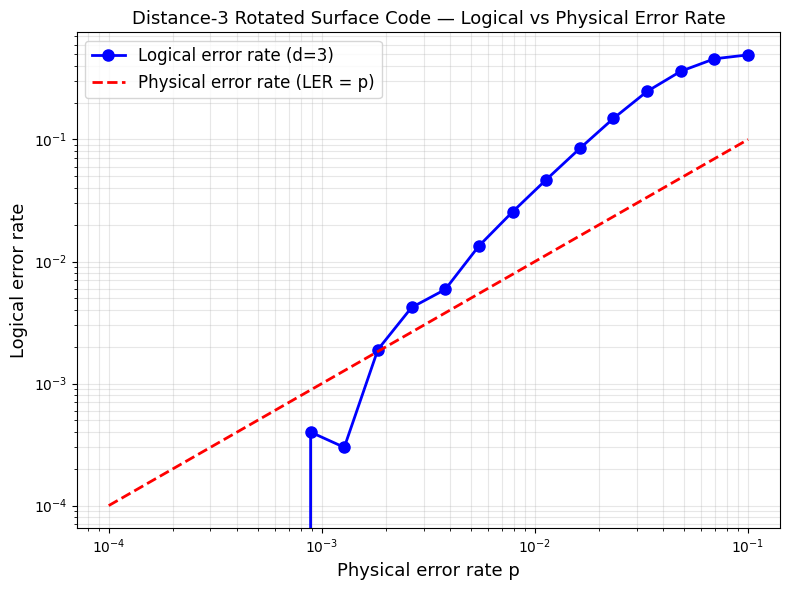

Plot saved to surface_code_ler.png


In [15]:
results = []
p_values = np.logspace(-4, -1, 20)
for p in p_values:
    code = RotatedSurfaceCodeLoom(distance = 5, n_cycles = 5, n_shots = 10000, noise = True, p = p)
    ler = code.run_circ("AER")
    results.append((p, ler))
    print(f"p={p:.5f} → LER={ler:.5f}  {'SUPPRESSED ✓' if ler < p else 'WORSE THAN PHYSICAL ✗'}")

plot_results(results)

In [ ]:
error_rates = []
for i in range(100):
    logical_error_rate = code.run_circ("MrAnderson")
    error_rates.append(logical_error_rate)
mean_error_rate = sum(error_rates) / len(error_rates)
print("Mean logical error rate:", mean_error_rate)
